# Spar buoy in Parcels: wind and depth-varying current

This notebook runs `SparBuoySimple` through the Parcels v4 coupling on an
idealized field, exercising the full `make_kernel` → `ParticleSet.execute`
path (unlike `01_spar_buoy_idealized`, which integrates the model ODE
directly).

The forcing is a two-medium profile on a single signed vertical axis:

- **Air** (above the surface) carries a uniform northward wind.
- **Water** (below the surface) carries an eastward current that decays with
  depth, from a surface value to zero at the buoy's draft.

The spar buoy feels wind drag on its emergent column and current drag along
its submerged hull, so it drifts as a drag-weighted blend of the two.

**Vertical convention.** The model samples with `z` positive upward (air at
`z > 0`, water at `z ≤ 0`). The Parcels fieldset uses a `depth` axis on which
we place the **air column at negative `depth`** and the **water column at
positive `depth`**; `mechanical_drifters.parcels` flips this to the model's
`z`-up frame when it extracts the profile. (Building such a merged
air/water fieldset from *real* ocean and atmosphere data is still open —
see `plans/BACKLOG.md`.)

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode

from mechanical_drifters.models.spar_buoy_simple import SparBuoySimple
from mechanical_drifters.parcels import make_kernel

/Users/wrath/src/github.com/geomar-od-lagrange/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_11798/3060726095.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode


In [2]:
U_wind = 0.0          # eastward wind [m/s]
V_wind = 10.0         # northward wind [m/s]
U_water_surface = 2.0  # eastward surface current [m/s]
V_water_surface = 0.0  # northward surface current [m/s]
draft = 10.0          # submerged hull length [m]

nx = 300              # grid points in x
ny = 150              # grid points in y
nz = 20               # water-column grid points
dt = 900.0            # integration timestep [s]
runtime = 21600.0     # total run [s] (6 h)
outputdt = 900.0      # output interval [s]

## Build the air/water fieldset

Air levels sit at negative `depth`, water levels at positive `depth`. The
eastward current decays as a half-cosine from `U_water_surface` at the surface
to zero at `draft`.

In [3]:
x = np.linspace(-200_000.0, 200_000.0, nx)
y = np.linspace(-50_000.0, 50_000.0, ny)

depth_air = np.linspace(-draft, 0.0, 11, endpoint=False)
depth_water = np.linspace(0.0, 100.0, nz)
depth = np.unique(np.concatenate([depth_air, depth_water]))

time = np.array([0.0])

Z, _, _ = np.meshgrid(depth, y, x, indexing="ij")

# Half-cosine current decay from the surface to the draft depth.
zz = np.clip(Z / draft, 0.0, 1.0)
U_water = U_water_surface * 0.5 * (1.0 + np.cos(np.pi * zz))
V_water = V_water_surface * 0.5 * (1.0 + np.cos(np.pi * zz))

# Air (depth < 0) gets the wind; water (depth >= 0) gets the current.
U = np.where(Z < 0, U_wind, U_water)
V = np.where(Z < 0, V_wind, V_water)

In [4]:
ds = xr.Dataset(
    {
        "U": (["time", "depth", "y", "x"], U[None, ...]),
        "V": (["time", "depth", "y", "x"], V[None, ...]),
        "grid": xr.DataArray(
            data=0,
            attrs={
                "cf_role": "grid_topology",
                "topology_dimension": 2,
                "node_dimensions": "x y",
                "face_dimensions": "x:x (padding: none) y:y (padding: none)",
                "vertical_dimensions": "depth:depth (padding: none)",
                "node_coordinates": "x y",
            },
        ),
    },
    coords={
        "x": ("x", x, {"axis": "X"}),
        "y": ("y", y, {"axis": "Y"}),
        "depth": ("depth", depth, {"axis": "Z"}),
        "time": ("time", time, {"axis": "T"}),
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds, mesh="flat")

## Release the buoys and integrate

In [5]:
spar = SparBuoySimple()
spar_kernel = make_kernel(spar)


def delete_out_of_bounds(particles, fieldset):
    """Convert out-of-bounds / through-surface errors to a Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (
        state == StatusCode.ErrorThroughSurface
    )
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

In [6]:
release_x = [1000.0, 2000.0, 3000.0, 4000.0]
release_y = [0.0, 1000.0, 2000.0, 3000.0]

pset = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_x,
    lat=release_y,
    z=[0.0] * len(release_x),
)

output_dir = Path("output_spar_buoy")
store = str(output_dir / "02_parcels_wind_and_current.zarr")
shutil.rmtree(store, ignore_errors=True)

pset.execute(
    kernels=[spar_kernel, delete_out_of_bounds],
    dt=dt,
    runtime=runtime,
    output_file=ParticleFile(store=store, outputdt=outputdt),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/mechanical_drifters/examples/spar_buoy/output_spar_buoy/02_parcels_wind_and_current.zarr


/Users/wrath/src/github.com/geomar-od-lagrange/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:281: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(
/Users/wrath/src/github.com/geomar-od-lagrange/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:286: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(
/Users/wrath/src/github.com/geomar-od-lagrange/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:293: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.equal(time, particle_data["time"], where=np.isfinite(particle_data["time"]))


## Trajectories

The buoys move eastward (water current) and northward (wind) — a drag-weighted
blend of the two media.

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_11798/3965438218.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_out = xr.open_zarr(store).load()


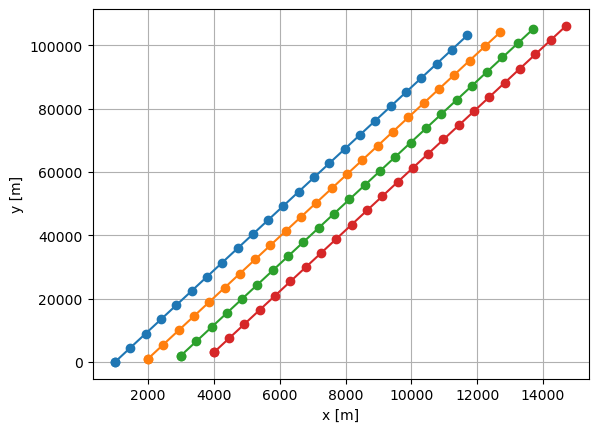

In [7]:
ds_out = xr.open_zarr(store).load()

fig, ax = plt.subplots()
for i in range(ds_out.sizes["trajectory"]):
    ax.plot(ds_out.lon.isel(trajectory=i), ds_out.lat.isel(trajectory=i), marker="o")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True)
plt.show()

In [8]:
final = ds_out.isel(obs=-1)
dx = (final.lon - ds_out.isel(obs=0).lon).mean().item()
dy = (final.lat - ds_out.isel(obs=0).lat).mean().item()
print(f"mean displacement over {runtime / 3600:.1f} h: dx={dx:.0f} m, dy={dy:.0f} m")
print(f"implied mean drift: u={dx / runtime:.3f} m/s, v={dy / runtime:.3f} m/s")

mean displacement over 6.0 h: dx=10696 m, dy=103178 m
implied mean drift: u=0.495 m/s, v=4.777 m/s
